# 04. Modelo Predictivo 03 - ¿En cuantos dias sera procesada la queja?

## Librerias

In [2]:
import numpy as np
import pandas as pd
import importlib
import matplotlib.pyplot as plt
import seaborn as sns
from math import sqrt
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, KFold, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, cohen_kappa_score
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import os
from sklearn.metrics import classification_report, confusion_matrix, cohen_kappa_score, roc_auc_score
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight

## Carga del dataset limpio

In [3]:
dt_quejas = pd.read_csv('..\data\dt_quejas_corr.csv')
dt_quejas.head(20)

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
C:\Users\Jon\AppData\Local\Temp\ipykernel_27108\93421454.py:1: SyntaxWarning: invalid escape sequence '\d'
  dt_quejas = pd.read_csv('..\data\dt_quejas_corr.csv')


,Complaint ID,Product,Sub-product,Issue,State,ZIP code,Date received,Date sent to company,Company,Company response,Timely response?,Consumer disputed?,Company_grouped_filtered,Difference in days
0,1291006,Debt collection,Credit card,Communication tactics,TX,76119,2015-03-19,2015-03-19,"Premium Asset Services, LLC",In progress,Yes,Pending,Low Count Companies,0
1,1290580,Debt collection,Medical,Cont'd attempts collect debt not owed,TX,77479,2015-03-19,2015-03-19,Accounts Receivable Consultants Inc.,Closed with explanation,Yes,No,Low Count Companies,0
2,1290564,Mortgage,FHA mortgage,"Application, originator, mortgage broker",MA,02127,2015-03-19,2015-03-19,RBS Citizens,Closed with explanation,Yes,Yes,RBS Citizens,0
3,1291615,Credit card,Unknown,Other,CA,92592,2015-03-19,2015-03-19,Navy FCU,In progress,Yes,Pending,Navy FCU,0
4,1292165,Debt collection,Non-federal student loan,Cont'd attempts collect debt not owed,OH,43068,2015-03-19,2015-03-19,Transworld Systems Inc.,In progress,Yes,Pending,Transworld Systems Inc.,0
5,1291176,Debt collection,Payday loan,Communication tactics,OH,43068,2015-03-19,2015-03-19,ACE Cash Express Inc.,In progress,Yes,Pending,ACE Cash Express Inc.,0
6,1288848,Consumer loan,Installment loan,Managing the loan or lease,OH,44241,2015-03-18,2015-03-18,"CashCall, Inc.",Closed with explanation,Yes,Yes,"CashCall, Inc.",0
7,1288788,Debt collection,Payday loan,Communication tactics,CA,95124,2015-03-18,2015-03-18,ACE Cash Express Inc.,Closed with explanation,Yes,No,ACE Cash Express Inc.,0
8,1288324,Debt collection,"Other (phone, health club, etc.)",Cont'd attempts collect debt not owed,NJ,07067,2015-03-18,2015-03-18,"Credit Protection Association, L.P.",Closed with non-monetary relief,Yes,No,Low Count Companies,0
9,1288304,Debt collection,Payday loan,Taking/threatening an illegal action,TX,77433,2015-03-18,2015-03-18,Cottonwood Financial Ltd.,Closed with explanation,Yes,Yes,Low Count Companies,0


In [3]:
X = dt_quejas.drop(columns=[
    'Difference in days', 
    'Complaint ID', 
    'Date received', 
    'Date sent to company', 'ZIP code', 'Company'
])
y = dt_quejas['Difference in days']

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Regresion Lineal

In [5]:
categorical_features = X.select_dtypes(include='object').columns.tolist()
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'
)
pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

In [6]:
pipe.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Product', 'Sub-product',
                                                   'Issue', 'State',
                                                   'Company response',
                                                   'Timely response?',
                                                   'Consumer disputed?',
                                                   'Company_grouped_filtered'])])),
                ('regressor', LinearRegression())])

MAE: 3.12
RMSE: 5.18
R²: 0.0937


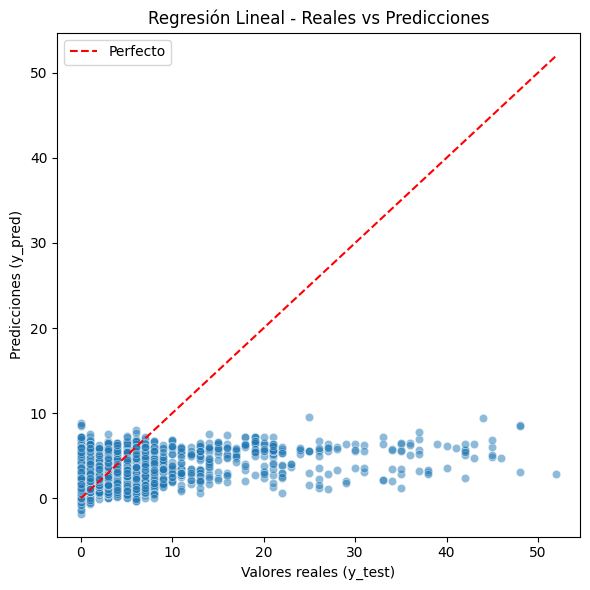

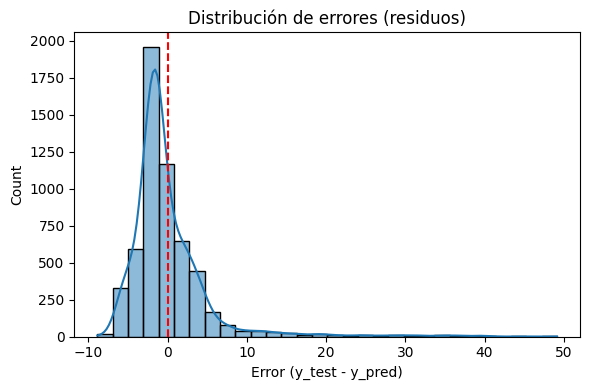

In [7]:
y_pred = pipe.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.4f}")

plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label="Perfecto")
plt.xlabel("Valores reales (y_test)")
plt.ylabel("Predicciones (y_pred)")
plt.title("Regresión Lineal - Reales vs Predicciones")
plt.legend()
plt.tight_layout()
plt.show()

errors = y_test - y_pred
plt.figure(figsize=(6,4))
sns.histplot(errors, bins=30, kde=True)
plt.axvline(0, color='red', linestyle='--')
plt.xlabel("Error (y_test - y_pred)")
plt.title("Distribución de errores (residuos)")
plt.tight_layout()
plt.show()

El modelo de Regresión Lineal muestra un desempeño bastante limitado para predecir el número de días de resolución. El valor de R² = 0.0937 indica que apenas explica un 9% de la variabilidad de los datos, lo que significa que la mayor parte de la dispersión en los tiempos de respuesta no está siendo capturada por este enfoque lineal. Esto ya nos advierte que la relación entre las variables predictoras y la variable objetivo probablemente no sea lineal.

El MAE = 3.12 y el RMSE = 5.18 confirman que el modelo comete errores relevantes: en promedio se desvía unos 3 días, con errores más grandes que pueden llegar a valores muy elevados (lo que se refleja en el RMSE mayor que el MAE). Esto es crítico en un contexto práctico. Al observar los gráficos, se aprecia que el modelo tiende a subestimar los valores altos de la variable objetivo: cuando los tiempos reales son grandes, las predicciones quedan muy por debajo de la línea de referencia (y = x). Por último, la distribución de errores muestra una asimetría con cola hacia la derecha, lo que significa que los casos con tiempos de respuesta largos generan errores muy grandes. En conjunto, estos resultados sugieren que la regresión lineal no es adecuada como modelo final y convendría explorar enfoques más flexibles

### Random Forest Regressor

In [8]:
def entrenar_rf_regresor(dt_quejas, drop_zip=True, random_state=42):

    y = pd.to_numeric(dt_quejas['Difference in days'], errors='coerce').fillna(0)
    cols_a_quitar = ['Difference in days', 'Complaint ID', 'Date received', 'Date sent to company', 'Company','ZIP code']

    X = dt_quejas.drop(columns=[c for c in cols_a_quitar if c in dt_quejas.columns]).copy()

    cat_cols = X.select_dtypes(include='object').columns.tolist()

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=random_state
    )

    preprocessor = ColumnTransformer(
        transformers=[('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)],
        remainder='passthrough'
    )

    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('rf', RandomForestRegressor(random_state=random_state, n_jobs=-1))
    ])

    param_grid = {
        'rf__n_estimators': [500, 750],
        'rf__max_depth': [None, 10, 20],
        'rf__min_samples_split': [6, 10],
        'rf__min_samples_leaf': [2,4],
        'rf__max_features': ['sqrt', 'log2']
    }

    grid = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        scoring='neg_mean_absolute_error',
        cv=5,
        n_jobs=-1,
        verbose=1,
        refit=True
    )

    grid.fit(X_train, y_train)
    best_model = grid.best_estimator_

    y_pred = best_model.predict(X_test)

    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)

    print(f"MAE:  {mae:.3f}")
    print(f"RMSE: {rmse:.3f}")
    print(f"R²:   {r2:.4f}")
    print("\nMejores parámetros:", grid.best_params_)
    print(f"Mejor MAE (CV): {-grid.best_score_:.3f}")

    plt.figure(figsize=(6,6))
    sns.scatterplot(x=y_test, y=y_pred, alpha=0.5)
    lim_min = min(y_test.min(), y_pred.min())
    lim_max = max(y_test.max(), y_pred.max())
    plt.plot([lim_min, lim_max], [lim_min, lim_max], 'r--', label='Perfecto')
    plt.xlabel("Valores reales (y_test)")
    plt.ylabel("Predicciones (y_pred)")
    plt.title("RandomForest Regressor - Reales vs Predicciones")
    plt.legend()
    plt.tight_layout()
    plt.show()

    residuos = y_test - y_pred
    plt.figure(figsize=(6,4))
    sns.histplot(residuos, bins=40, kde=True)
    plt.axvline(0, color='r', linestyle='--')
    plt.xlabel("Error (y_test - y_pred)")
    plt.title("Distribución de errores (residuos)")
    plt.tight_layout()
    plt.show()

    return best_model, grid

Fitting 5 folds for each of 48 candidates, totalling 240 fits
MAE:  3.106
RMSE: 5.148
R²:   0.1042

Mejores parámetros: {'rf__max_depth': None, 'rf__max_features': 'sqrt', 'rf__min_samples_leaf': 2, 'rf__min_samples_split': 10, 'rf__n_estimators': 750}
Mejor MAE (CV): 3.133


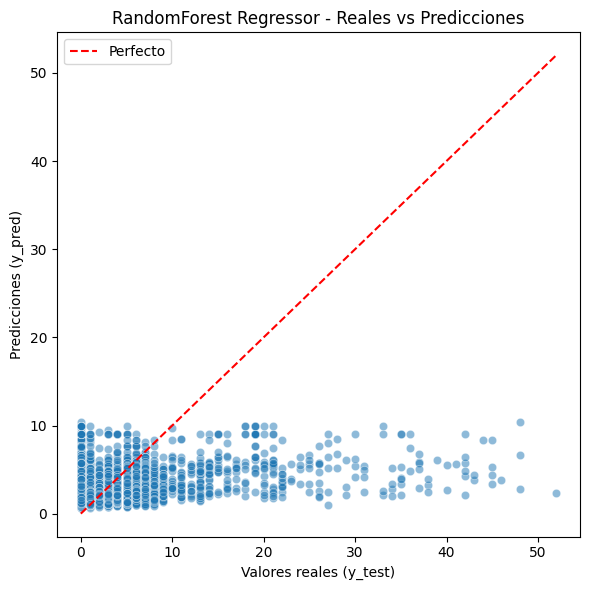

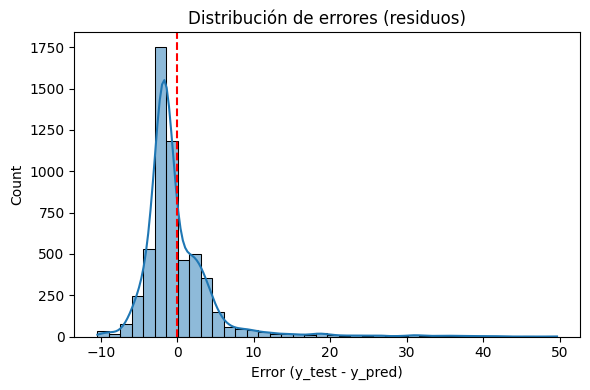

In [9]:
best_rf_reg, grid_rf_reg = entrenar_rf_regresor(dt_quejas)

El modelo de Random Forest Regressor apenas mejora respecto a la regresión lineal: obtiene un MAE de 3.106 y un RMSE de 5.148, prácticamente idénticos a los valores previos. El R² = 0.1042 indica que explica solo un 10% de la variabilidad, un incremento mínimo frente al modelo lineal. Esto sugiere que, aunque Random Forest es más flexible, la información disponible en las variables no está capturando bien la complejidad de los tiempos de resolución. En la gráfica de valores reales vs predicciones se observa nuevamente que el modelo se concentra en un rango bajo de predicciones (mayoritariamente entre 0 y 10 días). Esto significa que, igual que en la regresión lineal, el modelo subestima fuertemente los casos con tiempos largos de resolución, “aplanando” las predicciones y sin representar bien los extremos. En conjunto, el Random Forest aporta una ligera mejora técnica pero no suficiente para ser considerado un salto de calidad real.

### XGBoost Regressor

In [10]:
def entrenar_xgb_regresor(dt_quejas, random_state=42):
   
    cols_a_quitar = ['Difference in days', 'Complaint ID', 'Date received',
                     'Date sent to company', 'Company', 'ZIP code']

    y = pd.to_numeric(dt_quejas['Difference in days'], errors='coerce').fillna(0)

    X = dt_quejas.drop(columns=[c for c in cols_a_quitar if c in dt_quejas.columns]).copy()

    cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
    num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), num_cols),
            ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
        ],
        remainder='drop'
    )

    xgb = XGBRegressor(
        objective='reg:squarederror',
        tree_method='hist',
        random_state=random_state,
        n_jobs=-1
    )

    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('reg', xgb)
    ])

    param_grid = {
        'reg__n_estimators': [300, 500],
        'reg__max_depth': [3, 5, 7],
        'reg__learning_rate': [0.05, 0.1],
        'reg__subsample': [0.8, 1.0],
        'reg__colsample_bytree': [0.8, 1.0],
    }

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=random_state
    )

    y_train_log = np.log1p(y_train)
    y_test_log  = np.log1p(y_test)

    grid = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        scoring='neg_mean_absolute_error',
        cv=5, n_jobs=-1, verbose=1, refit=True
    )

    grid.fit(X_train, y_train_log)
    best_model = grid.best_estimator_

    y_pred_log = best_model.predict(X_test)
    y_pred = np.expm1(y_pred_log)

    mae  = mean_absolute_error(y_test, y_pred)
    rmse = sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)

    print(f"MAE:  {mae:.3f}")
    print(f"RMSE: {rmse:.3f}")
    print(f"R²:   {r2:.4f}")
    print("\nMejores parámetros:", grid.best_params_)
    print("Mejor MAE (CV):", -grid.best_score_)

    plt.figure(figsize=(6,6))
    plt.scatter(y_test, y_pred, alpha=0.5)
    max_ax = max(y_test.max(), y_pred.max())
    plt.plot([0, max_ax], [0, max_ax], 'r--', label='Perfecto')
    plt.xlabel('Valores reales (y_test)')
    plt.ylabel('Predicciones (y_pred)')
    plt.title('XGBoost Regressor - Reales vs Predicciones')
    plt.legend(); plt.tight_layout(); plt.show()

    resid = y_test - y_pred
    plt.figure(figsize=(6,4))
    sns.histplot(resid, bins=50, kde=True)
    plt.axvline(0, color='r', linestyle='--')
    plt.xlabel('Error (y_test - y_pred)')
    plt.title('Distribución de errores (residuos)')
    plt.tight_layout(); plt.show()

    return best_model, grid

Fitting 5 folds for each of 48 candidates, totalling 240 fits
MAE:  2.739
RMSE: 5.453
R²:   -0.0048

Mejores parámetros: {'reg__colsample_bytree': 0.8, 'reg__learning_rate': 0.05, 'reg__max_depth': 7, 'reg__n_estimators': 500, 'reg__subsample': 0.8}
Mejor MAE (CV): 0.747447932957226


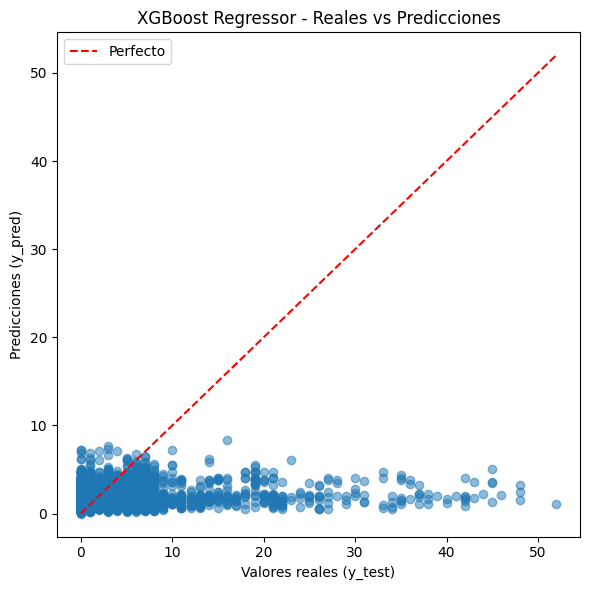

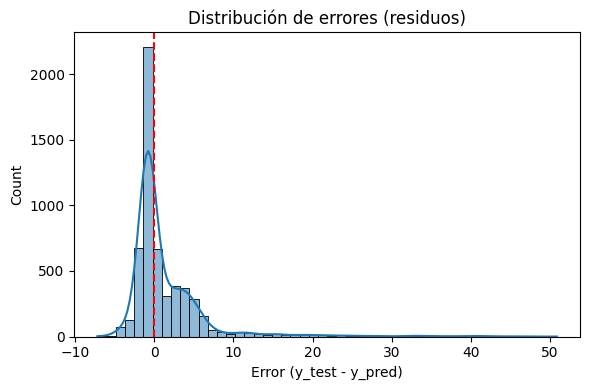

In [ ]:
best_xgb_reg, grid_xgb_reg = entrenar_xgb_regresor(dt_quejas)

El modelo de XGBoost Regressor presenta un comportamiento mixto. Por un lado, logra reducir el MAE a 2.739, lo que significa que en promedio se equivoca menos que los modelos anteriores (aproximadamente 0.4 días de mejora frente a regresión lineal y random forest). Sin embargo, el RMSE sube a 5.453 y el R² es negativo (-0.0048), lo que indica que en términos globales el modelo no explica mejor la variabilidad que una simple media. En la gráfica de predicciones vs valores reales se observa nuevamente la misma limitación: las predicciones se concentran en valores bajos (entre 0 y 10 días), sin lograr capturar bien los tiempos largos de resolución. Esto provoca que el modelo sea poco confiable en casos extremos, donde sistemáticamente subestima. En conjunto, XGBoost parece más preciso en la mayoría de los casos habituales (consultas rápidas), pero falla estrepitosamente en los casos largos. La diferencia entre MAE bajo y R² negativo revela que está sesgado hacia predecir valores cercanos al promedio

### Conversion a escala logaritmica

Vamos a probar si pasando la variable a escala logaritmica podemos conseguir un modelo mas fiable dada la alta asimetria que presenta esta variable. 

MAE: 2.76
RMSE: 5.49
R²: -0.0187


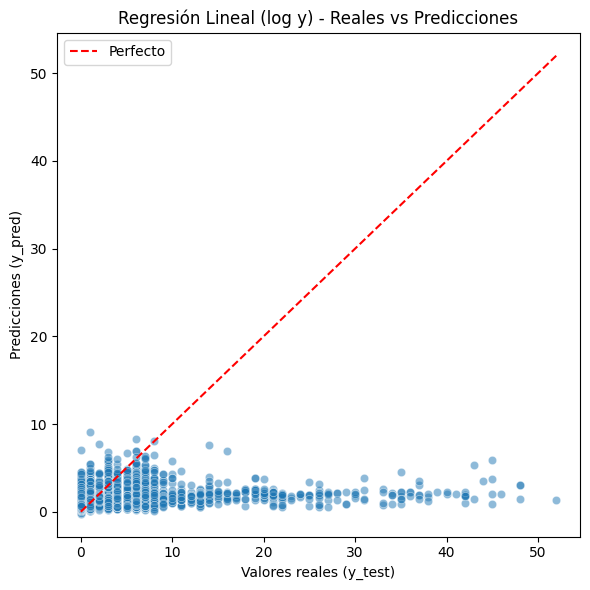

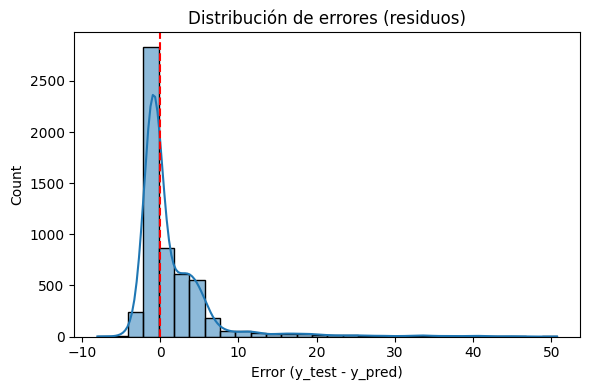

In [9]:
X = dt_quejas.drop(columns=[
    'Difference in days', 'Complaint ID', 'Date received',
    'Date sent to company', 'ZIP code', 'Company'
])
y = dt_quejas['Difference in days']

y_log = np.log1p(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)

categorical_features = X.select_dtypes(include='object').columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)],
    remainder='passthrough'
)

pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

pipe.fit(X_train, y_train)

y_pred_log = pipe.predict(X_test)

y_pred = np.expm1(y_pred_log)
y_test_original = np.expm1(y_test)

mae = mean_absolute_error(y_test_original, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_original, y_pred))
r2 = r2_score(y_test_original, y_pred)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.4f}")

plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test_original, y=y_pred, alpha=0.5)
plt.plot([y_test_original.min(), y_test_original.max()],
         [y_test_original.min(), y_test_original.max()],
         'r--', label="Perfecto")
plt.xlabel("Valores reales (y_test)")
plt.ylabel("Predicciones (y_pred)")
plt.title("Regresión Lineal (log y) - Reales vs Predicciones")
plt.legend()
plt.tight_layout()
plt.show()

errors = y_test_original - y_pred
plt.figure(figsize=(6,4))
sns.histplot(errors, bins=30, kde=True)
plt.axvline(0, color='red', linestyle='--')
plt.xlabel("Error (y_test - y_pred)")
plt.title("Distribución de errores (residuos)")
plt.tight_layout()
plt.show()

In [ ]:
def entrenar_rf_regresor_logy(dt_quejas, drop_zip=True, random_state=42):

    y = pd.to_numeric(dt_quejas['Difference in days'], errors='coerce').fillna(0)
    y_log = np.log1p(y)   

    cols_a_quitar = ['Difference in days', 'Complaint ID', 'Date received',
                     'Date sent to company', 'Company','ZIP code']

    X = dt_quejas.drop(columns=[c for c in cols_a_quitar if c in dt_quejas.columns]).copy()
    cat_cols = X.select_dtypes(include='object').columns.tolist()

    X_train, X_test, y_train, y_test = train_test_split(
        X, y_log, test_size=0.2, random_state=random_state
    )

    preprocessor = ColumnTransformer(
        transformers=[('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)],
        remainder='passthrough'
    )

    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('rf', RandomForestRegressor(random_state=random_state, n_jobs=-1))
    ])

    param_grid = {
        'rf__n_estimators': [500, 750],
        'rf__max_depth': [None, 10, 20],
        'rf__min_samples_split': [6, 10],
        'rf__min_samples_leaf': [2, 4],
        'rf__max_features': ['sqrt', 'log2']
    }

    grid = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        scoring='neg_mean_absolute_error',
        cv=5,
        n_jobs=-1,
        verbose=1,
        refit=True
    )

    grid.fit(X_train, y_train)
    best_model = grid.best_estimator_

    y_pred_log = best_model.predict(X_test)

    y_pred = np.expm1(y_pred_log)
    y_test_original = np.expm1(y_test)

    mae  = mean_absolute_error(y_test_original, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_original, y_pred))
    r2   = r2_score(y_test_original, y_pred)

    print(f"MAE:  {mae:.3f}")
    print(f"RMSE: {rmse:.3f}")
    print(f"R²:   {r2:.4f}")
    print("\nMejores parámetros:", grid.best_params_)
    print(f"Mejor MAE (CV): {-grid.best_score_:.3f}")

    plt.figure(figsize=(6,6))
    sns.scatterplot(x=y_test_original, y=y_pred, alpha=0.5)
    lim_min = min(y_test_original.min(), y_pred.min())
    lim_max = max(y_test_original.max(), y_pred.max())
    plt.plot([lim_min, lim_max], [lim_min, lim_max], 'r--', label='Perfecto')
    plt.xlabel("Valores reales (y_test)")
    plt.ylabel("Predicciones (y_pred)")
    plt.title("RandomForest Regressor (log y) - Reales vs Predicciones")
    plt.legend()
    plt.tight_layout()
    plt.show()

    residuos = y_test_original - y_pred
    plt.figure(figsize=(6,4))
    sns.histplot(residuos, bins=40, kde=True)
    plt.axvline(0, color='r', linestyle='--')
    plt.xlabel("Error (y_test - y_pred)")
    plt.title("Distribución de errores (residuos)")
    plt.tight_layout()
    plt.show()

    return best_model, grid

Fitting 5 folds for each of 48 candidates, totalling 240 fits
MAE:  2.753
RMSE: 5.477
R²:   -0.0137

Mejores parámetros: {'rf__max_depth': None, 'rf__max_features': 'sqrt', 'rf__min_samples_leaf': 2, 'rf__min_samples_split': 6, 'rf__n_estimators': 500}
Mejor MAE (CV): 0.754


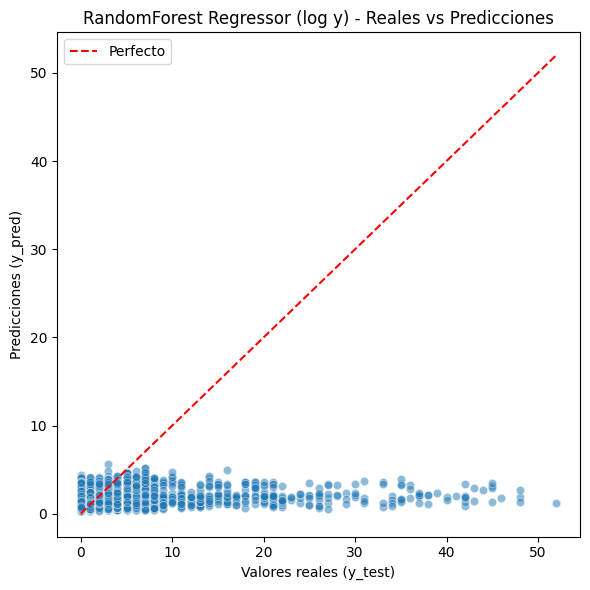

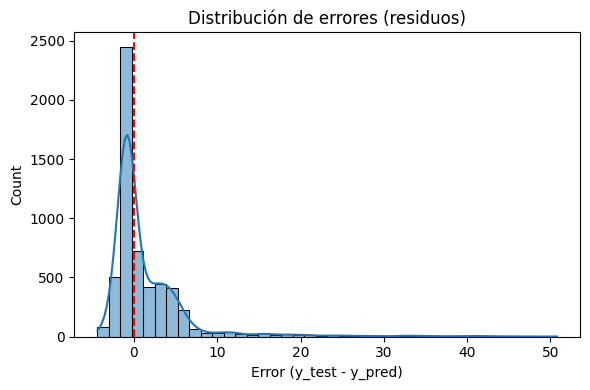

In [12]:
best_rf_log, grid_rf_log = entrenar_rf_regresor_logy(dt_quejas)


In [13]:
dt_quejas = pd.read_csv(r'..\data\dt_quejas_corr.csv')

def entrenar_xgb_regresor_logy(df, random_state=42):
    y = pd.to_numeric(df['Difference in days'], errors='coerce').fillna(0)
    X = df.drop(columns=[c for c in [
        'Difference in days', 'Complaint ID', 'Date received',
        'Date sent to company', 'Company', 'ZIP code'
    ] if c in df.columns]).copy()

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=random_state
    )

    y_train_log = np.log1p(y_train)
    y_test_log  = np.log1p(y_test)  

    cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
    num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), num_cols),
            ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
        ],
        remainder='drop'
    )


    xgb = XGBRegressor(
        objective='reg:squarederror',
        tree_method='hist',      # rápido
        random_state=random_state,
        n_jobs=-1
    )

    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('reg', xgb)
    ])


    param_grid = {
        'reg__n_estimators': [300, 500],
        'reg__max_depth': [3, 5, 7],
        'reg__learning_rate': [0.05, 0.1],
        'reg__subsample': [0.8, 1.0],
        'reg__colsample_bytree': [0.8, 1.0],
    }

    grid = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        scoring='neg_mean_absolute_error',
        cv=5, n_jobs=-1, verbose=1, refit=True
    )


    grid.fit(X_train, y_train_log)
    best_model = grid.best_estimator_


    y_pred_log = best_model.predict(X_test)
    y_pred = np.expm1(y_pred_log)

    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)

    print(f"MAE:  {mae:.3f}")
    print(f"RMSE: {rmse:.3f}")
    print(f"R²:   {r2:.4f}")
    print("\nMejores parámetros:", grid.best_params_)
    print(f"Mejor MAE (CV): {-grid.best_score_:.3f}")


    plt.figure(figsize=(6,6))
    plt.scatter(y_test, y_pred, alpha=0.5)
    max_ax = max(y_test.max(), y_pred.max())
    plt.plot([0, max_ax], [0, max_ax], 'r--', label='Perfecto')
    plt.xlabel('Valores reales (y_test)')
    plt.ylabel('Predicciones (y_pred)')
    plt.title('XGBoost Regressor (log y) - Reales vs Predicciones')
    plt.legend(); plt.tight_layout(); plt.show()


    resid = y_test - y_pred
    plt.figure(figsize=(6,4))
    sns.histplot(resid, bins=50, kde=True)
    plt.axvline(0, color='r', linestyle='--')
    plt.xlabel('Error (y_test - y_pred)')
    plt.title('Distribución de errores (residuos)')
    plt.tight_layout(); plt.show()

    return best_model, grid


Fitting 5 folds for each of 48 candidates, totalling 240 fits
MAE:  2.739
RMSE: 5.453
R²:   -0.0048

Mejores parámetros: {'reg__colsample_bytree': 0.8, 'reg__learning_rate': 0.05, 'reg__max_depth': 7, 'reg__n_estimators': 500, 'reg__subsample': 0.8}
Mejor MAE (CV): 0.747


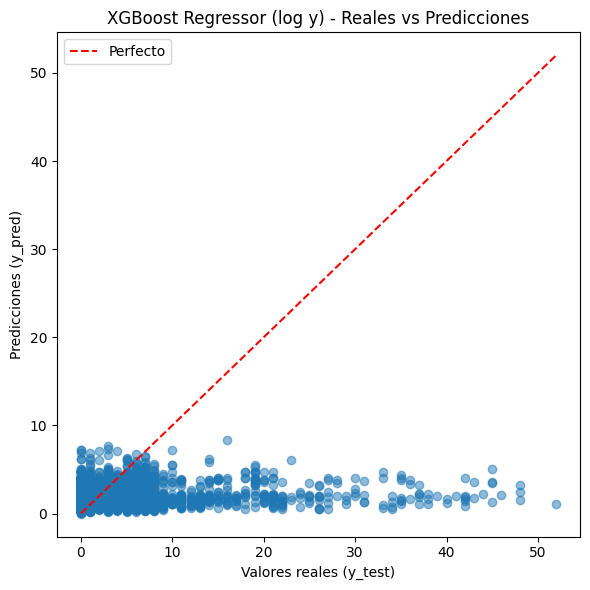

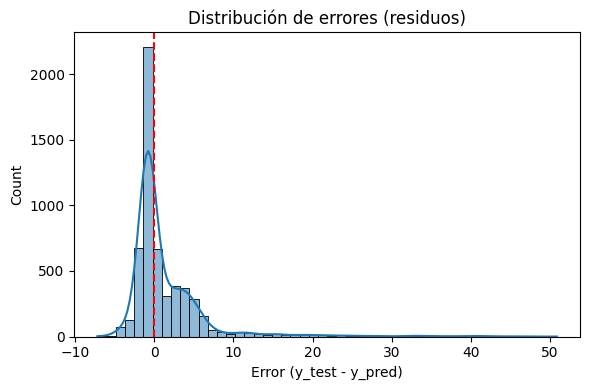

In [14]:
best_xgb_log, grid_xgb_log = entrenar_xgb_regresor_logy(dt_quejas)

Dados los resultados vamos a probar un modelo de clasificacion en rangos. 

In [52]:
def categorizar_dias(x):
    if x <= 3:
        return 0
    elif x <= 14:
        return 1
    else:
        return 2

dt_quejas["Delay_Class"] = dt_quejas["Difference in days"].apply(categorizar_dias)

In [53]:
cols_quitar = ['Difference in days','Complaint ID','Date received','Date sent to company','Company','ZIP code','Delay_Class']
X = dt_quejas.drop(columns=cols_quitar, errors='ignore')
y = dt_quejas['Delay_Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [54]:
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
    ],
    remainder='passthrough'
)

pipe = Pipeline(steps=[
    ('prep', preprocessor),
    ('clf', RandomForestClassifier(random_state=42, class_weight='balanced'))
])

param_grid = {
    'clf__n_estimators': [200, 500],
    'clf__max_depth': [None, 10, 20],
    'clf__min_samples_split': [2, 6],
    'clf__min_samples_leaf': [1, 2]
}

grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring='f1_macro',
    cv=5,
    n_jobs=-1,
    verbose=1,
    refit=True  
)

grid.fit(X_train, y_train)
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

print("Mejores parámetros:", grid.best_params_)
print("\nClassification report:\n", classification_report(y_test, y_pred))
print("Matriz de confusión:\n", confusion_matrix(y_test, y_pred, labels=best_model.named_steps['clf'].classes_))
print("Quadratic Weighted Kappa:", cohen_kappa_score(y_test, y_pred, weights='quadratic'))

if hasattr(best_model.named_steps['clf'], "predict_proba"):
    y_proba = best_model.predict_proba(X_test)  # (n_muestras, n_clases)
    classes_ = best_model.named_steps['clf'].classes_
    if len(classes_) == 2:
        
        y_proba_pos = y_proba[:, 1]
        auc = roc_auc_score(y_test, y_proba_pos)
        print(f"ROC AUC (binario): {auc:.4f}")
    else:
        
        auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro')
        print(f"ROC AUC (multiclase, ovr-macro): {auc:.4f}")
else:
    print("El clasificador no soporta predict_proba; no se puede calcular ROC AUC.")

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Mejores parámetros: {'clf__max_depth': 20, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 2, 'clf__n_estimators': 500}

Classification report:
               precision    recall  f1-score   support

           0       0.79      0.68      0.73      3926
           1       0.42      0.42      0.42      1501
           2       0.17      0.62      0.27       205

    accuracy                           0.61      5632
   macro avg       0.46      0.57      0.47      5632
weighted avg       0.67      0.61      0.63      5632

Matriz de confusión:
 [[2651  845  430]
 [ 676  634  191]
 [  34   43  128]]
Quadratic Weighted Kappa: 0.246068702324035
ROC AUC (multiclase, ovr-macro): 0.7106


El modelo alcanzó un AUC macro multiclase de 0.7106, lo que indica una capacidad de discriminación moderada entre las tres categorías. El accuracy del 61% muestra un desempeño aceptable, aunque aún con amplio margen de mejora. El Quadratic Weighted Kappa (≈0.25) señala un nivel de acuerdo bajo-moderado respecto a las etiquetas reales, lo que refleja que el modelo logra cierta diferenciación, pero no alcanza una clasificación consistente en todas las clases.

En el classification report, la clase 0 se mantiene como la mejor representada con un F1 de 0.73 y un recall del 68%, confirmando que el modelo identifica adecuadamente la mayoría de sus casos. La clase 1 obtiene un F1 de 0.42, con recall también de 0.42, lo que evidencia que el modelo consigue captar una fracción relevante de sus instancias, aunque con bastantes errores de clasificación.

La clase 2, la más minoritaria, muestra un F1 de 0.27, con un recall elevado (0.62) pero acompañado de una precisión baja. Esto significa que el modelo sí detecta una proporción significativa de ejemplos de esta clase, pero lo hace a costa de generar muchos falsos positivos. Este patrón es habitual en escenarios de desbalance, donde las clases con menos ejemplos tienden a sufrir más confusión con las mayoritarias.a dependencia del rendimiento en la clase 0 y la baja precisión en la clase 2 indican que se necesitan estrategias de mejora específicas para el desbalance, como ajustar pesos de clase en Random Forest, aplicar técnicas de sobremuestreo más afinadas o explorar algoritmos alternativos

In [55]:
cat_cols = X_train.select_dtypes(include="object").columns
num_cols = X_train.select_dtypes(exclude="object").columns

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

pipeline = ImbPipeline(steps=[
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("clf", RandomForestClassifier(random_state=42))
])

param_grid = {
    "clf__n_estimators": [200, 500],
    "clf__max_depth": [10, 20, None],
    "clf__min_samples_split": [2, 5],
    "clf__min_samples_leaf": [1, 2]
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    scoring="f1_macro",
    cv=5,
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

print("Mejores parámetros:", grid.best_params_)
print("\nClassification report:\n", classification_report(y_test, y_pred))
print("Matriz de confusión:\n", confusion_matrix(y_test, y_pred))
print("Quadratic Weighted Kappa:", cohen_kappa_score(y_test, y_pred, weights='quadratic'))


if hasattr(best_model.named_steps["clf"], "predict_proba"):
    y_proba = best_model.predict_proba(X_test)
    classes_ = best_model.named_steps["clf"].classes_
    
    if len(classes_) == 2:
        
        auc = roc_auc_score(y_test, y_proba[:, 1])
        print(f"ROC AUC (binario): {auc:.4f}")
    else:
        
        y_test_bin = label_binarize(y_test, classes=classes_)
        auc = roc_auc_score(y_test_bin, y_proba, average="macro", multi_class="ovr")
        print(f"ROC AUC (multiclase, OVR-macro): {auc:.4f}")
else:
    print("El clasificador no soporta predict_proba; no se puede calcular ROC AUC.")

Mejores parámetros: {'clf__max_depth': None, 'clf__min_samples_leaf': 2, 'clf__min_samples_split': 5, 'clf__n_estimators': 500}

Classification report:
               precision    recall  f1-score   support

           0       0.77      0.77      0.77      3926
           1       0.46      0.36      0.40      1501
           2       0.19      0.52      0.28       205

    accuracy                           0.65      5632
   macro avg       0.47      0.55      0.48      5632
weighted avg       0.67      0.65      0.65      5632

Matriz de confusión:
 [[3020  597  309]
 [ 831  533  137]
 [  60   38  107]]
Quadratic Weighted Kappa: 0.2594664925239156
ROC AUC (multiclase, OVR-macro): 0.7167


El Random Forest con SMOTE ha alcanzado un ROC AUC macro multiclase de 0.7167, lo que indica que en promedio logra diferenciar moderadamente bien entre las clases. El accuracy del 65% confirma que el modelo mejora respecto al azar y supera a la versión anterior, aunque todavía no alcanza un rendimiento óptimo. El kappa cuadrático de 0.26 señala un nivel de acuerdo bajo-moderado con las etiquetas verdaderas, condicionado por el desbalance de clases.

En las clases mayoritarias, el desempeño es claramente superior: la clase 0 consigue un F1 de 0.77 con un recall de 0.77, consolidándose como la más predecible. La clase 1 alcanza un F1 de 0.40 y un recall de 0.36, lo que muestra que sigue existiendo confusión con la clase 0, aunque SMOTE ha permitido capturar más ejemplos que en el ajuste anterior.

En la clase 2, la más minoritaria, el modelo mejora respecto a los intentos previos, logrando un F1 de 0.28 y un recall de 0.52. Esto significa que consigue identificar más de la mitad de los casos reales de esta categoría, aunque a costa de una precisión baja que incrementa los falsos positivos. Aun así, se aprecia que SMOTE ha tenido un efecto positivo al darle más visibilidad a esta clase.

En conjunto, el modelo presenta un buen rendimiento en la clase 0, un resultado aceptable en la clase 1 y una mejora notable en la clase 2 gracias al sobremuestreo. Sin embargo, sigue existiendo un desequilibrio en la calidad de las predicciones, con las clases minoritarias aportando menos al rendimiento global

#### XGBoost + GridSearch

In [56]:
cols_quitar = ['Difference in days','Complaint ID','Date received',
               'Date sent to company','Company','ZIP code','Delay_Class']
X = dt_quejas.drop(columns=cols_quitar, errors='ignore')
y = dt_quejas['Delay_Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

cat_cols = X_train.select_dtypes(include='object').columns.tolist()
num_cols = X_train.select_dtypes(exclude='object').columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=True), cat_cols),
        ('num', 'passthrough', num_cols)
    ]
)

xgb = XGBClassifier(
    objective="multi:softprob",
    num_class=len(np.unique(y)),
    use_label_encoder=False,
    eval_metric="mlogloss",
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

param_grid = {
    "clf__n_estimators": [200, 500],
    "clf__max_depth": [5, 10, 20],
    "clf__learning_rate": [0.05, 0.1],
    "clf__subsample": [0.8, 1.0],
    "clf__colsample_bytree": [0.8, 1.0]
}

pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("clf", xgb)
])

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=3,
    scoring="f1_macro",   
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("Mejores parámetros:", grid.best_params_)

best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

print("\nClassification report:\n", classification_report(y_test, y_pred))
print("\nMatriz de confusión:\n", confusion_matrix(y_test, y_pred))
print("Quadratic Weighted Kappa:", cohen_kappa_score(y_test, y_pred, weights="quadratic"))

if hasattr(best_model.named_steps["clf"], "predict_proba"):
    y_proba = best_model.predict_proba(X_test)
    classes_ = best_model.named_steps["clf"].classes_
    
    if len(classes_) == 2:
        auc = roc_auc_score(y_test, y_proba[:, 1])
        print(f"ROC AUC (binario): {auc:.4f}")
    else:
        y_test_bin = label_binarize(y_test, classes=classes_)
        auc = roc_auc_score(y_test_bin, y_proba, average="macro", multi_class="ovr")
        print(f"ROC AUC (multiclase, OVR-macro): {auc:.4f}")

Fitting 3 folds for each of 48 candidates, totalling 144 fits


c:\Users\Jon\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [23:32:09] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Mejores parámetros: {'clf__colsample_bytree': 1.0, 'clf__learning_rate': 0.1, 'clf__max_depth': 20, 'clf__n_estimators': 200, 'clf__subsample': 1.0}

Classification report:
               precision    recall  f1-score   support

           0       0.73      0.90      0.81      3926
           1       0.49      0.26      0.34      1501
           2       0.30      0.07      0.12       205

    accuracy                           0.70      5632
   macro avg       0.51      0.41      0.42      5632
weighted avg       0.65      0.70      0.66      5632


Matriz de confusión:
 [[3522  377   27]
 [1107  386    8]
 [ 170   20   15]]
Quadratic Weighted Kappa: 0.14965251788482903
ROC AUC (multiclase, OVR-macro): 0.7052


El modelo de XGBoost con Grid Search alcanzó un ROC AUC macro multiclase de 0.7052, lo que indica que, en promedio, el clasificador logra una discriminación moderada entre las tres clases. El accuracy del 70% supone una mejora clara frente a los experimentos previos, pero el Quadratic Weighted Kappa (≈0.15) revela que el acuerdo con las etiquetas reales sigue siendo bajo, lo que refleja que el modelo aún no consigue un desempeño equilibrado en todas las categorías.

En el classification report, la clase 0 se mantiene como la más robusta, con un F1 de 0.81 y un recall elevado (0.90), lo que significa que el modelo identifica la gran mayoría de ejemplos de esta clase. En contraste, la clase 1 se queda en un F1 de 0.34 y un recall de 0.26, lo que muestra que muchos de sus ejemplos siguen siendo absorbidos por la clase 0, aunque con una precisión moderada (0.49).

La clase 2, la más minoritaria, sigue siendo la más difícil de predecir, con un F1 de apenas 0.12 y un recall de 0.07, reflejando que el modelo apenas logra reconocer algunos de sus casos reales. La matriz de confusión confirma esta dificultad: la mayoría de instancias de la clase 2 son clasificadas como clase 0, lo que evidencia la fuerte tendencia del modelo a favorecer la clase mayoritaria.

En conjunto, XGBoost ha permitido incrementar la precisión global del sistema y mejorar sustancialmente el rendimiento en la clase 0, pero a costa de mantener un desempeño limitado en las clases minoritarias.

#### XGBoost con ajuste de pesos

In [ ]:
cols_quitar = ['Difference in days','Complaint ID','Date received',
               'Date sent to company','Company','ZIP code','Delay_Class']
X = dt_quejas.drop(columns=cols_quitar, errors='ignore')
y = dt_quejas['Delay_Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

cat_cols = X_train.select_dtypes(include='object').columns.tolist()
num_cols = X_train.select_dtypes(exclude='object').columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=True), cat_cols),
        ('num', 'passthrough', num_cols)
    ]
)

classes = np.unique(y_train)
class_weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, class_weights))
print("Pesos de clase:", class_weight_dict)

xgb = XGBClassifier(
    objective="multi:softprob",
    num_class=len(classes),
    use_label_encoder=False,
    eval_metric="mlogloss",
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

param_grid = {
    "clf__n_estimators": [200, 500],
    "clf__max_depth": [5, 10, 20],
    "clf__learning_rate": [0.05, 0.1],
    "clf__subsample": [0.8, 1.0],
    "clf__colsample_bytree": [0.8, 1.0]
}

pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("clf", xgb)
])

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=3,
    scoring="f1_macro",   
    n_jobs=-1,
    verbose=1
)

sample_weights = y_train.map(class_weight_dict)

grid.fit(X_train, y_train, clf__sample_weight=sample_weights)

print("Mejores parámetros:", grid.best_params_)

best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

print("\nClassification report:\n", classification_report(y_test, y_pred))
print("\nMatriz de confusión:\n", confusion_matrix(y_test, y_pred))
print("Quadratic Weighted Kappa:", cohen_kappa_score(y_test, y_pred, weights="quadratic"))

if hasattr(best_model.named_steps["clf"], "predict_proba"):
    y_proba = best_model.predict_proba(X_test)
    classes_ = best_model.named_steps["clf"].classes_
    
    if len(classes_) == 2:
        auc = roc_auc_score(y_test, y_proba[:, 1])
        print(f"ROC AUC (binario): {auc:.4f}")
    else:
        y_test_bin = label_binarize(y_test, classes=classes_)
        auc = roc_auc_score(y_test_bin, y_proba, average="macro", multi_class="ovr")
        print(f"ROC AUC (multiclase, OVR-macro): {auc:.4f}")

Pesos de clase: {np.int64(0): np.float64(0.47812519900655925), np.int64(1): np.float64(1.2513333333333334), np.int64(2): np.float64(9.144945188794154)}
Fitting 3 folds for each of 48 candidates, totalling 144 fits


c:\Users\Jon\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [23:54:31] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Mejores parámetros: {'clf__colsample_bytree': 0.8, 'clf__learning_rate': 0.05, 'clf__max_depth': 10, 'clf__n_estimators': 200, 'clf__subsample': 1.0}

Classification report:
               precision    recall  f1-score   support

           0       0.80      0.62      0.70      3926
           1       0.40      0.48      0.44      1501
           2       0.16      0.63      0.25       205

    accuracy                           0.58      5632
   macro avg       0.45      0.58      0.46      5632
weighted avg       0.67      0.58      0.61      5632


Matriz de confusión:
 [[2419 1030  477]
 [ 573  720  208]
 [  30   45  130]]
Quadratic Weighted Kappa: 0.2311528176480765
ROC AUC (multiclase, OVR-macro): 0.7129


El modelo de XGBoost con ajuste de pesos alcanzó un ROC AUC macro multiclase de 0.7129, lo que indica que, en promedio, el clasificador logra una discriminación moderada entre las tres clases. El accuracy global del 58% muestra que el rendimiento mejora respecto al azar, pero todavía está lejos de ser óptimo. El Quadratic Weighted Kappa (≈0.23) refuerza esta conclusión, señalando que el nivel de acuerdo con las etiquetas reales es bajo-moderado, lo que refleja que el desbalance de clases sigue afectando de manera notable al modelo.

El classification report confirma que la clase 0 es la más sólida, con un F1 de 0.70 y un recall del 62%. Esto significa que el modelo es capaz de identificar una mayoría de casos de esta clase, aunque sigue confundiendo un número considerable con la clase 1. En la clase 1, el desempeño es más modesto, con un F1 de 0.44 y un recall de 0.48, mostrando que el modelo capta casi la mitad de los ejemplos, pero con un nivel importante de falsos positivos y falsos negativos.

En la clase 2, la más minoritaria, el modelo logra un recall elevado de 0.63, lo que indica que detecta buena parte de los casos reales, pero a costa de una precisión muy baja que deja el F1 en 0.25. Esto se refleja en la matriz de confusión: de 205 ejemplos reales, 130 se clasifican correctamente, pero muchos otros se confunden con las clases 0 y 1. Esto sugiere que el ajuste de pesos ayuda a que el modelo “mire más” hacia la clase 2, pero todavía no logra separar bien sus patrones.

En conjunto, puedo concluir que el modelo es fuerte en la clase mayoritaria, aceptable en la clase intermedia y débil pero con cierta mejora en la minoritaria. La estrategia de ajuste de pesos ha permitido elevar el recall de las clases con menos representación, aunque penalizando el rendimiento global en términos de precisión

### Analisis Comparativo

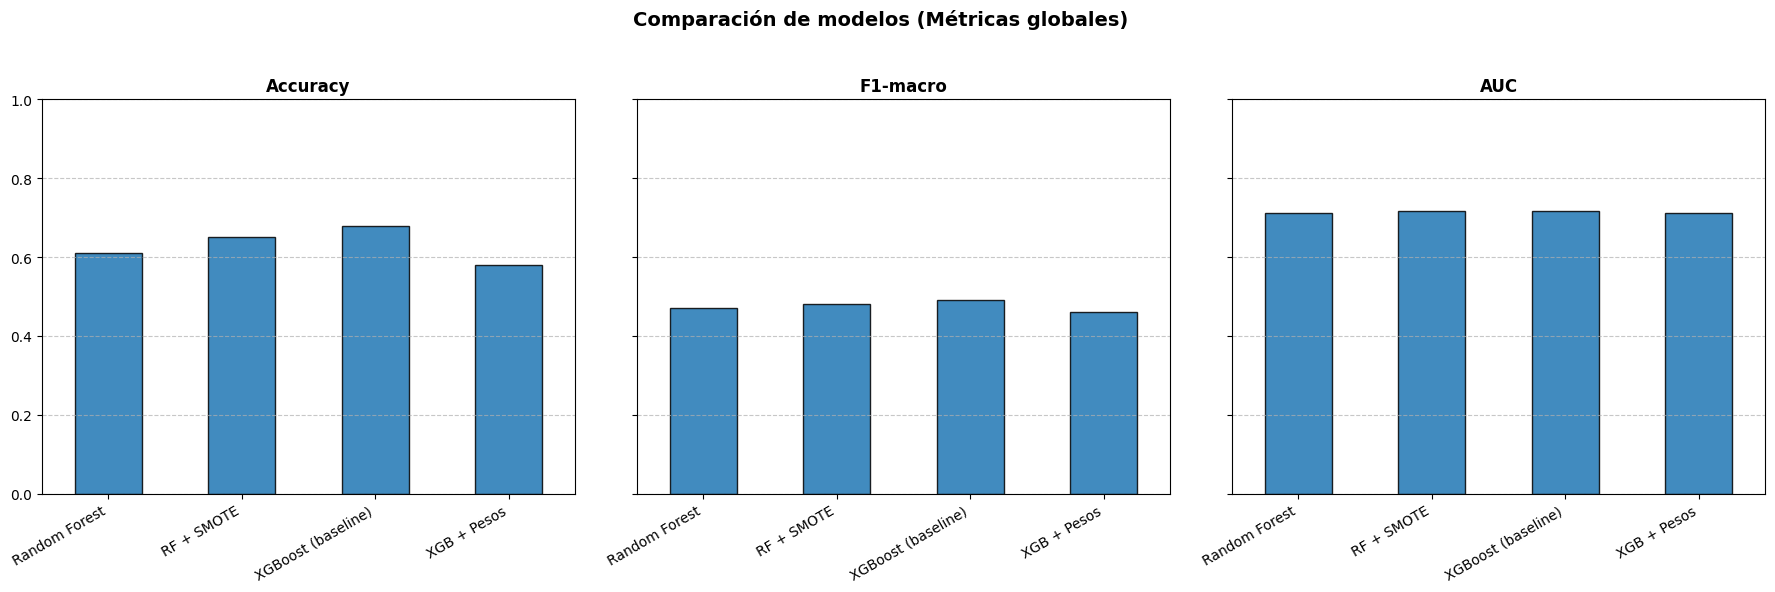

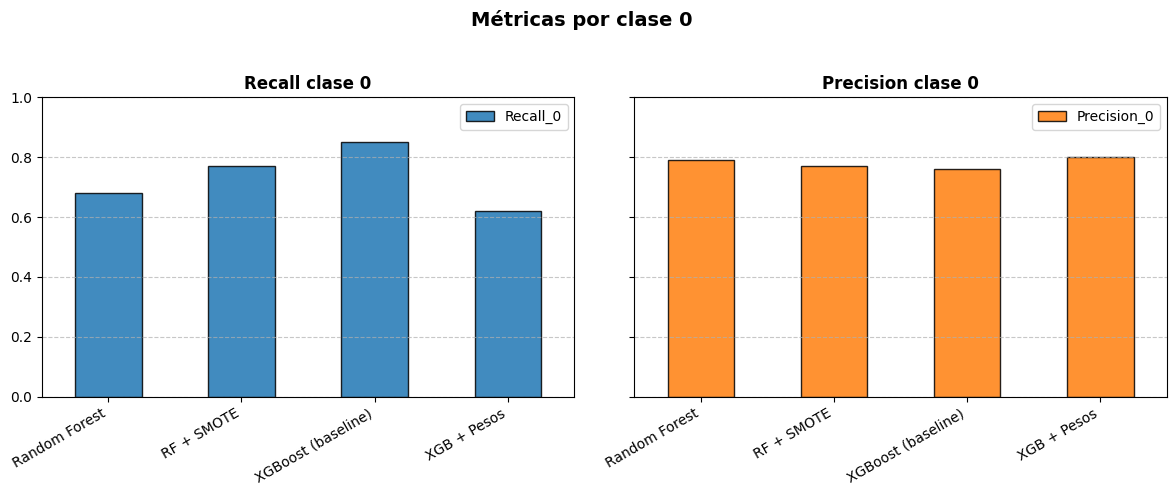

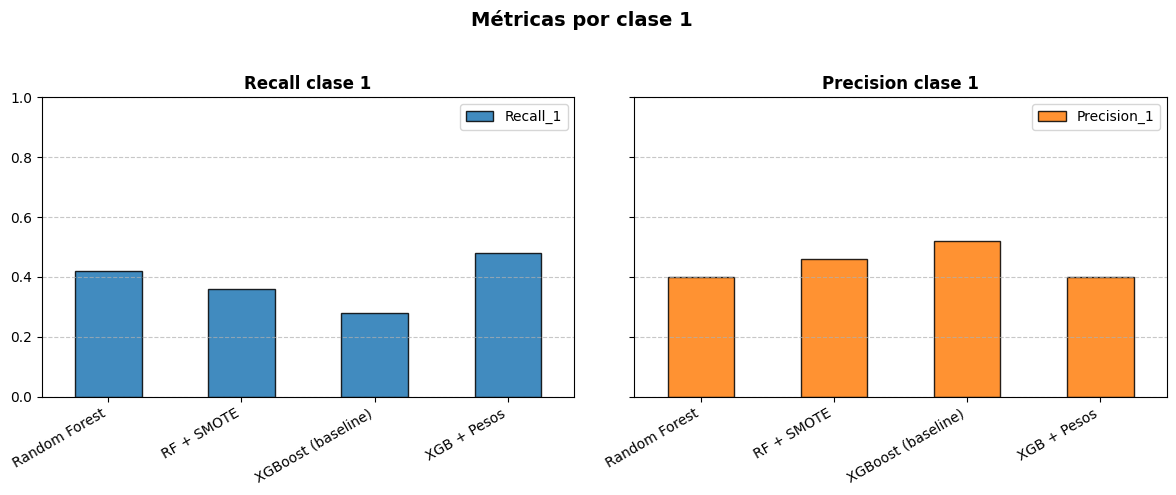

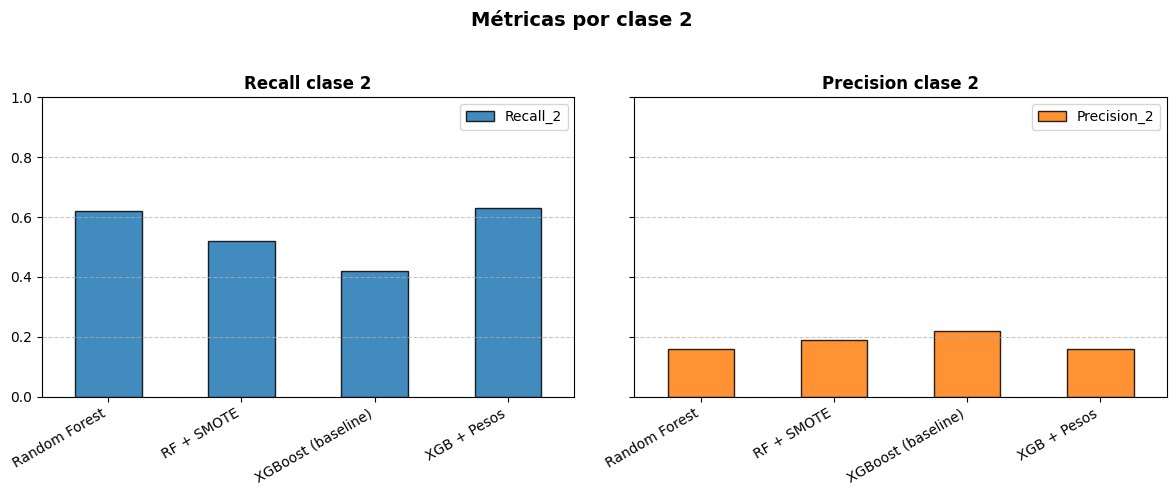

In [6]:
resultados = { 
    "Random Forest": {
        "Accuracy": 0.61,
        "F1-macro": 0.47,
        "AUC": 0.7106,
        "Recall_0": 0.68, "Precision_0": 0.79,
        "Recall_1": 0.42, "Precision_1": 0.40,
        "Recall_2": 0.62, "Precision_2": 0.16,
        "QWK": 0.20
    },
    "RF + SMOTE": {
        "Accuracy": 0.65,
        "F1-macro": 0.48,
        "AUC": 0.7167,
        "Recall_0": 0.77, "Precision_0": 0.77,
        "Recall_1": 0.36, "Precision_1": 0.46,
        "Recall_2": 0.52, "Precision_2": 0.19,
        "QWK": 0.26
    },
    "XGBoost (baseline)": {
        "Accuracy": 0.68,
        "F1-macro": 0.49,
        "AUC": 0.7162,
        "Recall_0": 0.85, "Precision_0": 0.76,
        "Recall_1": 0.28, "Precision_1": 0.52,
        "Recall_2": 0.42, "Precision_2": 0.22,
        "QWK": 0.25
    },
    "XGB + Pesos": {
        "Accuracy": 0.58,
        "F1-macro": 0.46,
        "AUC": 0.7129,
        "Recall_0": 0.62, "Precision_0": 0.80,
        "Recall_1": 0.48, "Precision_1": 0.40,
        "Recall_2": 0.63, "Precision_2": 0.16,
        "QWK": 0.23
    }
}
df_resultados = pd.DataFrame(resultados).T
metricas_globales = ["Accuracy", "F1-macro", "AUC"]

fig, axes = plt.subplots(1, len(metricas_globales), figsize=(18, 6), sharey=True)
for i, metrica in enumerate(metricas_globales):
    df_resultados[metrica].plot(
        kind="bar",
        ax=axes[i],
        alpha=0.85,
        edgecolor="black"
    )
    axes[i].set_title(metrica, fontsize=12, fontweight="bold")
    axes[i].set_ylim(0, 1)
    axes[i].grid(axis="y", linestyle="--", alpha=0.7)
    axes[i].set_xticklabels(df_resultados.index, rotation=30, ha="right")

plt.suptitle("Comparación de modelos (Métricas globales)", fontsize=14, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

clases = ["0", "1", "2"]
for c in clases:
    fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
    df_resultados[[f"Recall_{c}"]].plot(kind="bar", ax=ax[0], color="#1f77b4", edgecolor="black", alpha=0.85)
    df_resultados[[f"Precision_{c}"]].plot(kind="bar", ax=ax[1], color="#ff7f0e", edgecolor="black", alpha=0.85)
    
    ax[0].set_title(f"Recall clase {c}", fontsize=12, fontweight="bold")
    ax[1].set_title(f"Precision clase {c}", fontsize=12, fontweight="bold")
    
    for a in ax:
        a.set_ylim(0, 1)
        a.grid(axis="y", linestyle="--", alpha=0.7)
        a.set_xticklabels(df_resultados.index, rotation=30, ha="right")
    
    plt.suptitle(f"Métricas por clase {c}", fontsize=14, fontweight="bold")
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

El Random Forest mostró un accuracy del 61% y un ROC AUC macro de ~0.71, con un Kappa de ~0.25. La clase 0 fue la mejor representada (F1 ≈ 0.73), mientras que las clases 1 y 2 tuvieron un rendimiento bastante menor (F1 ≈ 0.42 y 0.27, respectivamente). El modelo tendió a predecir en exceso la clase mayoritaria, absorbiendo ejemplos de las minoritarias. Aun así, ofreció un buen punto de partida y mostró solidez en la clase dominante.

La aplicación de SMOTE permitió equilibrar algo más las clases y se reflejó en una ligera mejora. El accuracy subió al 65%, el AUC macro se mantuvo cerca de 0.72 y el Kappa alcanzó 0.26. La clase 0 mantuvo un buen rendimiento (F1 ≈ 0.77), mientras que la clase 1 se quedó en valores moderados (F1 ≈ 0.40). La gran novedad fue la clase 2, que alcanzó un recall del 52% (mucho mayor que en el RF clásico), aunque con baja precisión (F1 ≈ 0.28). Esto demuestra que el sobremuestreo ayudó a que el modelo “viera” mejor a las clases minoritarias, aunque a costa de más falsos positivos.

El modelo de XGBoost, tanto en su versión baseline como con Randomized Search, logró el mejor desempeño global con un accuracy del 68% y un AUC macro de ~0.716. Además, alcanzó un Kappa de ~0.25 y, en el caso del Randomized Search, un ligero incremento (QWK ≈ 0.254). La clase 0 fue muy bien capturada (F1 ≈ 0.80, recall ≈ 0.85), confirmando que XGBoost maneja mejor la clase mayoritaria. La clase 1 mostró un rendimiento limitado (F1 ≈ 0.36, recall ≈ 0.28), mientras que la clase 2 alcanzó un recall de 0.42 con un F1 de 0.29. En general, el modelo equilibró mejor la precisión global, aunque no resolvió del todo los problemas con las clases minoritarias.

En resumen, todos los modelos coincidieron en un AUC macro ≈ 0.71–0.72, lo que sugiere que comparten una capacidad de discriminación moderada. El Random Forest clásico fue consistente en la clase mayoritaria, pero flojo en minoritarias. La variante RF con SMOTE mejoró notablemente el recall de la clase 2, aunque sacrificando precisión. Finalmente, XGBoost con Randomized Search se consolidó como el mejor modelo, al mantener el mayor accuracy global (68%), una discriminación competitiva (AUC ≈ 0.716) y la mejor concordancia ordinal (QWK ≈ 0.254), lo que lo convierte en la opción más equilibrada entre rendimiento y generalización.

In [22]:
ruta = r"C:\Users\Jon\Documents\Repositorios\Proyectos_DS2025\Proyecto Fin de Modulo ML\data"
os.makedirs(ruta, exist_ok=True)

dt_quejas.to_csv(os.path.join(ruta, "dt_quejas_modelo.csv"), index=False)